# 📊 ShareStats Dataset Exploration
This notebook analyzes the publicly available **ShareStats** item bank referenced in  
*“ShareStats: An open statistics item bank developed by a community of instructors in higher education (Namesnik-Silvester et al., 2025).”*  

We will:
1. Load the dataset directly from the ShareStats GitHub repository.  
2. Inspect metadata columns and structure.  
3. Analyze the distribution of questions by topic, question type, and cognitive level.  
4. Visualize these distributions.

In [31]:
# 🧩 Step 1: Import dependencies
import pandas as pd
import matplotlib.pyplot as plt

# Display plots inline
%matplotlib inline

In [32]:
# 📥 Step 2: Load the dataset
url = "https://sharestats.github.io/itembank/sharestats_website.csv"
all_items = pd.read_csv(url)

# Add GitHub link for each question
all_items["Path"] = "https://github.com/ShareStats/itembank/tree/main/" + all_items["folder"].astype(str)

# Display summary info
print(f"Number of items: {len(all_items)}")
print("\nColumn names:")
print(all_items.columns.tolist())

# Preview first few rows
all_items.head()


Number of items: 9196

Column names:
['Unnamed: 0', 'id', 'folder', 'name', 'question', 'Item Type', 'Section', 'Type', 'Program', 'Language', 'Level', 'Path']


,Unnamed: 0,id,folder,name,question,Item Type,Section,Type,Program,Language,Level,Path
0,1,0.0,Assumptions/eur-assumptions-101-en,eur-assumptions-101-en,*Testing effect* \nResearch has shown that whe...,num,Assumptions/Homogeneity of variance/Levene's test,Performing analysis,SPSS,English,Statistical Literacy,https://github.com/ShareStats/itembank/tree/ma...
1,2,1.0,Assumptions/eur-assumptions-101-nl,eur-assumptions-101-nl,*Testing effect* \nUit onderzoek is gebleken d...,num,Assumptions/Homogeneity of variance/Levene's test,Performing analysis,SPSS,Dutch,Statistical Literacy,https://github.com/ShareStats/itembank/tree/ma...
2,3,2.0,Assumptions/eur-assumptions-102-en,eur-assumptions-102-en,*Testing effect* \nResearch has shown that whe...,num,Assumptions/Homogeneity of variance/Levene's t...,Performing analysis,SPSS,English,Statistical Literacy,https://github.com/ShareStats/itembank/tree/ma...
3,4,3.0,Assumptions/eur-assumptions-102-nl,eur-assumptions-102-nl,*Testing effect* \nUit onderzoek is gebleken d...,num,Assumptions/Homogeneity of variance/Levene's t...,Performing analysis,SPSS,Dutch,Statistical Literacy,https://github.com/ShareStats/itembank/tree/ma...
4,5,4.0,Assumptions/eur-assumptions-103-en,eur-assumptions-103-en,"*Long-term detention*\nCurrently, in the Nethe...",num,"Assumptions/Sphericity/Epsilon, Inferential St...",Performing analysis,SPSS,English,Statistical Literacy,https://github.com/ShareStats/itembank/tree/ma...


In [33]:
# Normalize column names so they're easy to use
all_items.columns = (
    all_items.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

all_items.columns.tolist()

['unnamed:_0',
 'id',
 'folder',
 'name',
 'question',
 'item_type',
 'section',
 'type',
 'program',
 'language',
 'level',
 'path']

In [34]:
# 🌍 Filter to only English questions
# Convert language column to string and normalize for comparison
all_items["language"] = all_items["language"].astype(str).str.strip().str.lower()

# Filter for English questions (handles variations like "english", "English", "EN", etc.)
english_items = all_items[all_items["language"].str.contains("english", case=False, na=False)]

# Update all_items to only contain English questions
all_items = english_items.copy()

print(f"Number of English items: {len(all_items)}")
print(f"Number of items filtered out: {9196 - len(all_items)}")
print("\nLanguage distribution in filtered data:")
print(all_items["language"].value_counts())


Number of English items: 4549
Number of items filtered out: 4647

Language distribution in filtered data:
language
english    4549
Name: count, dtype: int64


In [35]:
# 🧠 Step 3: Basic metadata overview (updated for ShareStats schema)
for col in ["section", "item_type", "level"]:
    if col not in all_items.columns:
        raise KeyError(f"Expected column '{col}' not found. Available: {all_items.columns.tolist()}")

print("Unique Sections (topics):", all_items["section"].nunique())
print("Unique Item Types (format):", all_items["item_type"].nunique())
print("Unique Levels (cognitive):", all_items["level"].nunique())

# Peek at the categorical distributions
display(all_items["section"].value_counts().head(20))
display(all_items["item_type"].value_counts())
display(all_items["level"].value_counts())


Unique Sections (topics): 611
Unique Item Types (format): 5
Unique Levels (cognitive): 12


section
Inferential Statistics/Parametric Techniques/ANOVA/Oneway ANOVA                    136
Inferential Statistics/Parametric Techniques/ANOVA/Twoway ANOVA                    120
Inferential Statistics/Parametric Techniques/z-test                                105
Inferential Statistics/Non-parametric Techniques/Binomial test                     103
Inferential Statistics/NHST/Power                                                  101
Inferential Statistics/Regression/Equation                                          94
Descriptive statistics/Summary Statistics/Bivariate statistics/Correlation          94
Inferential Statistics/Regression/Multiple linear regression                        87
Probability/Elementary Probability                                                  85
Inferential Statistics/NHST/Test statistic/Chi-squared                              83
Inferential Statistics/Parametric Techniques/t-test/Paired samples                  82
Distributions/Continuous/Normal    

item_type
schoice    4164
num         313
string       50
cloze        21
mchoice       1
Name: count, dtype: int64

level
Statistical Literacy     3481
statistical literacy      379
Statistical Thinking      262
statistical reasoning     151
Statistical Reasoning     129
statistical thinking      102
Statistical Literacy       18
Statistical literacy        1
Interpretating output       1
Statistical Thinking        1
statistical analysis        1
statisitcal reasoning       1
Name: count, dtype: int64

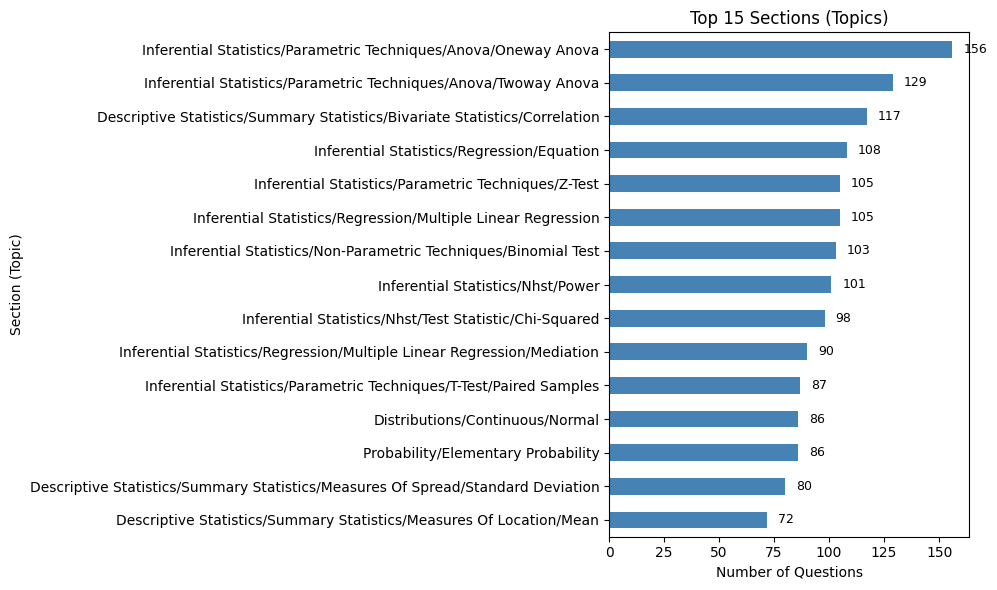

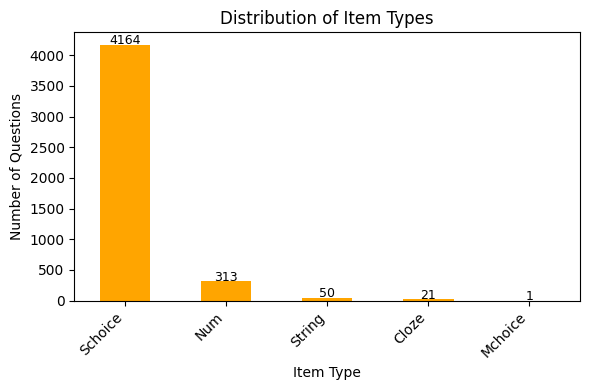

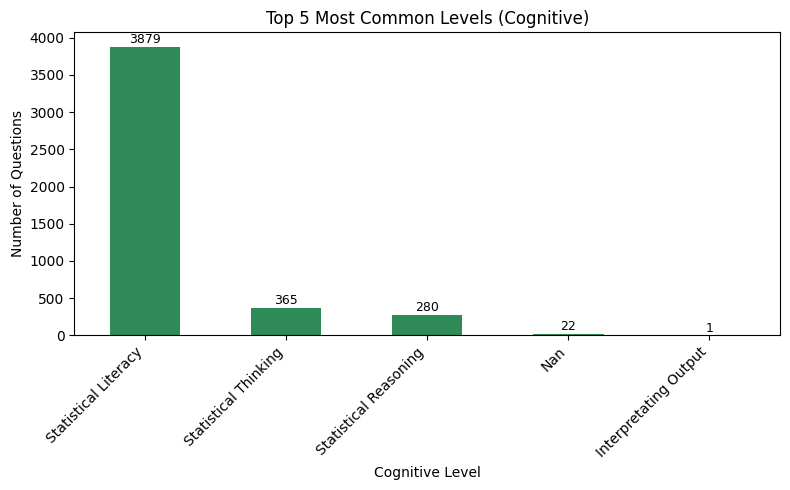

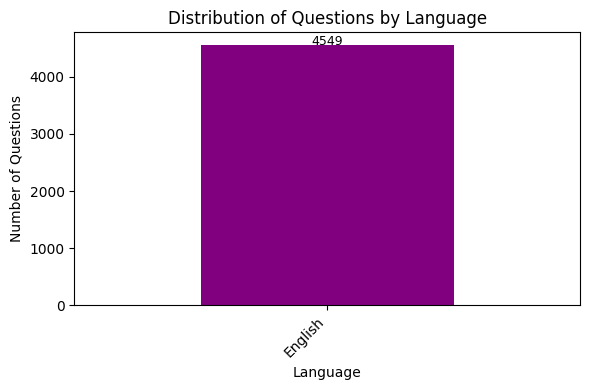

In [36]:
import matplotlib.pyplot as plt

# 🧹 Clean text columns for consistency
for col in ["section", "item_type", "level", "language"]:
    all_items[col] = all_items[col].astype(str).str.strip().str.title()

# 📊 Top 15 Sections (Topics)
section_counts = all_items["section"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = section_counts.head(15).plot(kind="barh", color="steelblue")
plt.title("Top 15 Sections (Topics)")
plt.xlabel("Number of Questions")
plt.ylabel("Section (Topic)")
plt.gca().invert_yaxis()

# Add value labels to bars
for i, v in enumerate(section_counts.head(15)):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 📋 Item Type Distribution
item_counts = all_items["item_type"].value_counts()
plt.figure(figsize=(6, 4))
ax = item_counts.plot(kind="bar", color="orange")
plt.title("Distribution of Item Types")
plt.ylabel("Number of Questions")
plt.xlabel("Item Type")
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, v in enumerate(item_counts):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 🧠 Cognitive Level Distribution (Cleaned + Top N)
level_counts = all_items["level"].value_counts()
top_n = 5  # adjust as needed
top_levels = level_counts.head(top_n)

plt.figure(figsize=(8, 5))
ax = top_levels.plot(kind="bar", color="seagreen")
plt.title(f"Top {top_n} Most Common Levels (Cognitive)")
plt.ylabel("Number of Questions")
plt.xlabel("Cognitive Level")
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, v in enumerate(top_levels):
    ax.text(i, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 🌍 Distribution by Language
language_counts = all_items["language"].value_counts()
plt.figure(figsize=(6, 4))
ax = language_counts.plot(kind="bar", color="purple")
plt.title("Distribution of Questions by Language")
plt.ylabel("Number of Questions")
plt.xlabel("Language")
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, v in enumerate(language_counts):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# 📝 Item Type Explanations

The ShareStats dataset uses 5 different question formats:

1. **Schoice (Single Choice)** - Multiple choice questions with **one correct answer**. Students select a single option from a list. This is the most common format (4,164 questions).

2. **Mchoice (Multiple Choice)** - Multiple choice questions where **multiple answers can be correct**. Students may need to select all correct options. This is the rarest format (only 1 question).

3. **Num (Numerical)** - Questions requiring a **numerical answer**. Students enter a number, which may be evaluated as an exact value or within a specified range (313 questions).

4. **String (Short Answer)** - Questions requiring a **text/string response**. Students provide a brief free-text answer, typically a word or short phrase (50 questions).

5. **Cloze (Fill-in-the-Blank)** - Questions with **missing words or phrases** in a passage. Students fill in the blanks, which can be implemented as drag-and-drop, dropdown menus, or text input (21 questions).


In [37]:
# 🔍 Examples of Each Item Type
print("Examples of each question type:\n")
print("=" * 80)

for item_type in ["Schoice", "Mchoice", "Num", "String", "Cloze"]:
    # Find an example of this type (case-insensitive)
    example = all_items[all_items["item_type"].str.lower() == item_type.lower()].iloc[0]
    print(f"\n{item_type.upper()} Example:")
    print(f"Section: {example['section']}")
    print(f"\nFull Question (includes answer options/answer):")
    print("-" * 80)
    print(example['question'])
    print("-" * 80)
    print(f"GitHub Link: {example['path']}")
    print("=" * 80)


Examples of each question type:


SCHOICE Example:
Section: Assumptions/Sphericity/Mauchly'S Test, Inferential Statistics/Parametric Techniques/Anova/Oneway Repeated Measures Anova

Full Question (includes answer options/answer):
--------------------------------------------------------------------------------
In a one-way repeated measures ANOVA, a researcher needs to test, amongst other assumptions, the sphericity assumption. Consider the following statements about the sphericity assumption and answer the subsequent question. 
1. This assumption does not apply when the within-subjects factor only has two levels. 
2. When this assumption is severely violated, a researcher can use a repeated-measures multivariate test (MANOVA) as an alternative to the uncorrected F-test. 
Which statement is true?
Answerlist
----------
* both statements are true
* only statement 1 is true
* only statement 2 is true
* both statements are false

-------------------------------------------------------------

In [38]:
summary = pd.DataFrame({
    "count": all_items.shape[0],
    "n_sections": all_items["section"].nunique(),
    "n_item_types": all_items["item_type"].nunique(),
    "n_levels": all_items["level"].nunique(),
}, index=["sharestats"])
summary


,count,n_sections,n_item_types,n_levels
sharestats,4549,519,5,7
